In [1]:
import os
import zipfile

# Tải dữ liệu
!curl -O https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

# Giải nén
with zipfile.ZipFile("kagglecatsanddogs_5340.zip", "r") as zip_ref:
    zip_ref.extractall("data")

# Đường dẫn tới thư mục ảnh
data_dir = "data/PetImages"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  786M  100  786M    0     0   295M      0  0:00:02  0:00:02 --:--:--  295M


In [ ]:
def clean_data(root_dir):
    num_skipped = 0
    for folder_name in ("Cat", "Dog"):
        folder_path = os.path.join(root_dir, folder_name)
        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)
            try:
                with open(fpath, "rb") as fobj:
                    is_jfif = b"JFIF" in fobj.peek(10)
                if not is_jfif:
                    num_skipped += 1
                    os.remove(fpath)
            except Exception:
                num_skipped += 1
                if os.path.exists(fpath):
                    os.remove(fpath)
    print(f"Đã xóa {num_skipped} ảnh lỗi.")

clean_data(data_dir)

Đã xóa 1590 ảnh lỗi.


In [3]:
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import Subset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

image_size = (180, 180)
batch_size = 32

# Augmentation giống Keras
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# 2. Lấy danh sách index cho từng lớp
# full_dataset.targets chứa nhãn (0 cho Cat, 1 cho Dog)
indices = np.arange(len(full_dataset))
labels = np.array(full_dataset.targets)

cat_indices = indices[labels == 0][:100] # Lấy 100 index đầu tiên của Cat
dog_indices = indices[labels == 1][:100] # Lấy 100 index đầu tiên của Dog

# Gộp lại thành một danh sách index duy nhất
limited_indices = np.concatenate([cat_indices, dog_indices])

# 3. Tạo Subset từ các index đã chọn
limited_dataset = Subset(full_dataset, limited_indices)

# 4. Chia Train/Val từ dataset đã giới hạn (ví dụ 80/20 của 200 ảnh)
train_size = int(0.8 * len(limited_dataset))
val_size = len(limited_dataset) - train_size
train_ds, val_ds = random_split(limited_dataset, [train_size, val_size])

# Khởi tạo DataLoader
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

print(f"✅ Tổng số ảnh sử dụng: {len(limited_dataset)}")
print(f"Số lớp: {full_dataset.classes}")

✅ Tổng số ảnh sử dụng: 200
Số lớp: ['Cat', 'Dog']


In [4]:
class SeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False),
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class XceptionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.entry = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        # Residual Blocks
        self.block1 = SeparableConv(64, 128)
        self.res1 = nn.Conv2d(64, 128, 1, stride=1)
        
        self.block2 = SeparableConv(128, 256, stride=2)
        self.res2 = nn.Conv2d(128, 256, 1, stride=2)

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.entry(x)
        x = self.block1(x) + self.res1(x)
        x = self.block2(x) + self.res2(x)
        return self.head(x)

In [14]:
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = XceptionModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

def train_one_epoch():
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Tính Accuracy (vì đầu ra là Sigmoid nên > 0.5 là Dog, < 0.5 là Cat)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

# Trong vòng lặp chính
for epoch in range(50):
    loss, acc = train_one_epoch()
    print(f"Epoch {epoch+1:02d} | Loss: {loss:.4f} | Acc: {acc:.2f}%")
torch.save(model.state_dict(), 'model_weights.pth')


Epoch 01 | Loss: 0.6886 | Acc: 53.75%
Epoch 02 | Loss: 0.6735 | Acc: 59.38%
Epoch 03 | Loss: 0.6517 | Acc: 63.12%
Epoch 04 | Loss: 0.6336 | Acc: 66.25%
Epoch 05 | Loss: 0.5964 | Acc: 68.75%
Epoch 06 | Loss: 0.5798 | Acc: 68.75%
Epoch 07 | Loss: 0.5769 | Acc: 68.75%
Epoch 08 | Loss: 0.5907 | Acc: 70.00%
Epoch 09 | Loss: 0.5499 | Acc: 71.88%
Epoch 10 | Loss: 0.5502 | Acc: 71.25%
Epoch 11 | Loss: 0.5793 | Acc: 71.25%
Epoch 12 | Loss: 0.5972 | Acc: 66.88%
Epoch 13 | Loss: 0.5748 | Acc: 69.38%
Epoch 14 | Loss: 0.5449 | Acc: 75.00%
Epoch 15 | Loss: 0.5277 | Acc: 73.75%
Epoch 16 | Loss: 0.5644 | Acc: 68.75%
Epoch 17 | Loss: 0.5150 | Acc: 74.38%
Epoch 18 | Loss: 0.5914 | Acc: 67.50%
Epoch 19 | Loss: 0.5816 | Acc: 71.88%
Epoch 20 | Loss: 0.5329 | Acc: 74.38%
Epoch 21 | Loss: 0.5144 | Acc: 72.50%
Epoch 22 | Loss: 0.5155 | Acc: 73.75%
Epoch 23 | Loss: 0.5156 | Acc: 75.62%
Epoch 24 | Loss: 0.5194 | Acc: 77.50%
Epoch 25 | Loss: 0.5240 | Acc: 71.88%
Epoch 26 | Loss: 0.5201 | Acc: 73.75%
Epoch 27 | L

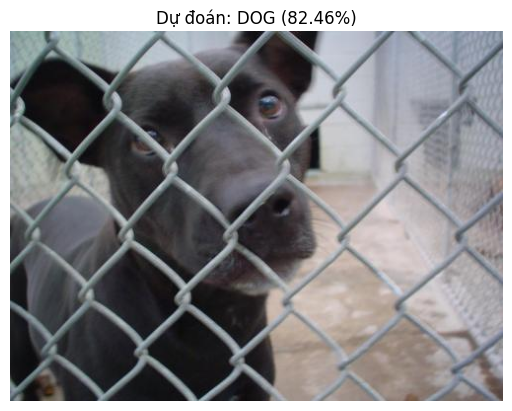

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = XceptionModel().to(device)

model.load_state_dict(torch.load('model_weights.pth', map_location=device))
model.eval() # CHẾ ĐỘ QUAN TRỌNG: Tắt Dropout và BatchNorm

image_size = (180, 180)
predict_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
])

def predict_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img_tensor = predict_transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(img_tensor)
        probability = output.item()

    if probability > 0.5:
        label = "DOG"
        confidence = probability
    else:
        label = "CAT"
        confidence = 1 - probability
        
    plt.imshow(img)
    plt.title(f"Dự đoán: {label} ({confidence:.2%})")
    plt.axis('off')
    plt.show()

predict_image("/kaggle/working/data/PetImages/Dog/10019.jpg")